### Imports && Load

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])
test = pd.read_csv('../data/raw/test.csv', parse_dates=['Date'])
store = pd.read_csv('../data/raw/store.csv')

print("train:", train.shape)
print("test:", test.shape)
print("store:", store.shape)

/tmp/ipykernel_16872/1494100840.py:7: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('../data/raw/train.csv', parse_dates=['Date'])


train: (1017209, 9)
test: (41088, 8)
store: (1115, 10)


In [4]:
df = train.merge(store, on='Store', how='left')
print(df.shape)
df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


### Dtypes && nulls

In [5]:
print("=== dtypes ===")
print(df.dtypes)
print()
print("=== null counts ===")
print(df.isnull().sum())

=== dtypes ===
Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
dtype: object

=== null counts ===
Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers     

### Basic Statistics

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Store,1017209.0,NaN,NaN,NaN,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,NaN,NaN,NaN,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,NaN,NaN,NaN,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,NaN,NaN,NaN,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,NaN,NaN,NaN,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,NaN,NaN,NaN,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,NaN,NaN,NaN,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
StateHoliday,1017209,5,0,855087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SchoolHoliday,1017209.0,NaN,NaN,NaN,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
StoreType,1017209,4,a,551627,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Date Range && Continuity check

In [7]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Unique dates:", df['Date'].nunique())
print("Unique stores:", df['Store'].nunique())

# expected rows if every store had a row for every date
expected_rows = df['Date'].nunique() * df['Store'].nunique()
print("Expected rows (dates x stores):", expected_rows)
print("Actual rows:", len(df))
print("Difference:", expected_rows - len(df))

Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Unique dates: 942
Unique stores: 1115
Expected rows (dates x stores): 1050330
Actual rows: 1017209
Difference: 33121


### Stores with missing data

In [8]:
rows_per_store = df.groupby('Store')['Date'].count()
print("Rows per store — min/max/mean:")
print(rows_per_store.min(), rows_per_store.max(), rows_per_store.mean())
print()
print("Stores with fewer rows than the max (potential gaps):")
print(rows_per_store[rows_per_store < rows_per_store.max()].shape[0], "stores")
rows_per_store[rows_per_store < rows_per_store.max()].sort_values().head(10)

Rows per store — min/max/mean:
758 942 912.295067264574

Stores with fewer rows than the max (potential gaps):
181 stores


Store
13    758
20    758
22    758
32    758
36    758
41    758
46    758
51    758
52    758
58    758
Name: Date, dtype: int64

### Validate Sales == 0

In [9]:
print("Rows where Open==0:", (df['Open'] == 0).sum())
print("Rows where Sales==0:", (df['Sales'] == 0).sum())
print()
print("Rows where Open==0 but Sales>0 (should be 0):", ((df['Open'] == 0) & (df['Sales'] > 0)).sum())
print("Rows where Open==1 but Sales==0 (interesting edge case):", ((df['Open'] == 1) & (df['Sales'] == 0)).sum())

Rows where Open==0: 172817
Rows where Sales==0: 172871

Rows where Open==0 but Sales>0 (should be 0): 0
Rows where Open==1 but Sales==0 (interesting edge case): 54


### Which date range is missing for the gap stores?

In [10]:
gap_stores = rows_per_store[rows_per_store < rows_per_store.max()].index.tolist()

sample_gap_store = gap_stores[0]
store_dates = df[df['Store'] == sample_gap_store]['Date'].sort_values()

print(f"Store {sample_gap_store} — date range present:", store_dates.min(), "to", store_dates.max())
print("Number of dates:", store_dates.nunique())

# find the actual gap
full_range = pd.date_range(store_dates.min(), store_dates.max(), freq='D')
missing_dates = full_range.difference(store_dates)
print("Missing dates within its own range:", len(missing_dates))
if len(missing_dates) > 0:
    print("First few missing:", missing_dates[:5].tolist())
    print("Last few missing:", missing_dates[-5:].tolist())

Store 13 — date range present: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Number of dates: 758
Missing dates within its own range: 184
First few missing: [Timestamp('2014-07-01 00:00:00'), Timestamp('2014-07-02 00:00:00'), Timestamp('2014-07-03 00:00:00'), Timestamp('2014-07-04 00:00:00'), Timestamp('2014-07-05 00:00:00')]
Last few missing: [Timestamp('2014-12-27 00:00:00'), Timestamp('2014-12-28 00:00:00'), Timestamp('2014-12-29 00:00:00'), Timestamp('2014-12-30 00:00:00'), Timestamp('2014-12-31 00:00:00')]


### Confirm this pattern is shared across most/all gap stores (same missing window)

In [11]:
gap_summary = df[df['Store'].isin(gap_stores)].groupby('Store')['Date'].agg(['min', 'max', 'count'])
gap_summary.head(10)

,min,max,count
Store,,,
13,2013-01-01,2015-07-31,758
20,2013-01-01,2015-07-31,758
22,2013-01-01,2015-07-31,758
32,2013-01-01,2015-07-31,758
36,2013-01-01,2015-07-31,758
41,2013-01-01,2015-07-31,758
46,2013-01-01,2015-07-31,758
51,2013-01-01,2015-07-31,758
52,2013-01-01,2015-07-31,758


### Quick look at the Open==1 but Sales==0 rows

In [12]:
df[(df['Open'] == 1) & (df['Sales'] == 0)][['Store', 'Date', 'DayOfWeek', 'Sales', 'Customers', 'Promo', 'StateHoliday', 'SchoolHoliday']].head(15)

,Store,Date,DayOfWeek,Sales,Customers,Promo,StateHoliday,SchoolHoliday
86825,971,2015-05-15,5,0,0,0,0,1
142278,674,2015-03-26,4,0,0,0,0,0
196938,699,2015-02-05,4,0,0,1,0,0
322053,708,2014-10-01,3,0,0,1,0,0
330176,357,2014-09-22,1,0,0,0,0,0
340348,227,2014-09-11,4,0,0,0,0,0
340860,835,2014-09-11,4,0,0,0,0,0
341795,835,2014-09-10,3,0,0,0,0,0
346232,548,2014-09-05,5,0,0,1,0,1
346734,28,2014-09-04,4,0,0,1,0,0


### Sales distribution (open days only)

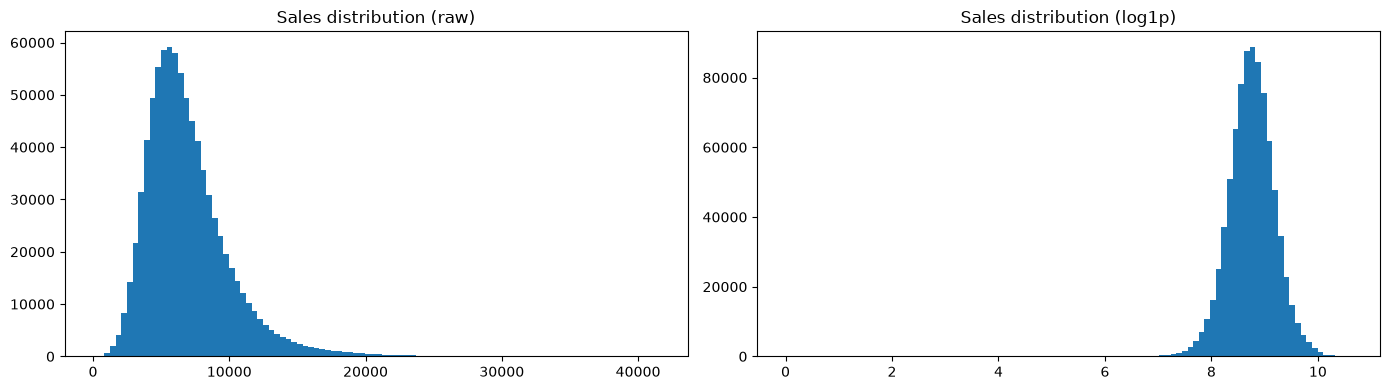

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64

Skew (raw): 1.5939220392699807
Skew (log1p): -0.6379710294195982


In [15]:
open_df = df[df['Open'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(open_df['Sales'], bins=100)
axes[0].set_title('Sales distribution (raw)')

axes[1].hist(np.log1p(open_df['Sales']), bins=100)
axes[1].set_title('Sales distribution (log1p)')
plt.tight_layout()
plt.show()

print(open_df['Sales'].describe())
print()
print("Skew (raw):", open_df['Sales'].skew())
print("Skew (log1p):", np.log1p(open_df['Sales']).skew())

### Aggregate sales over time

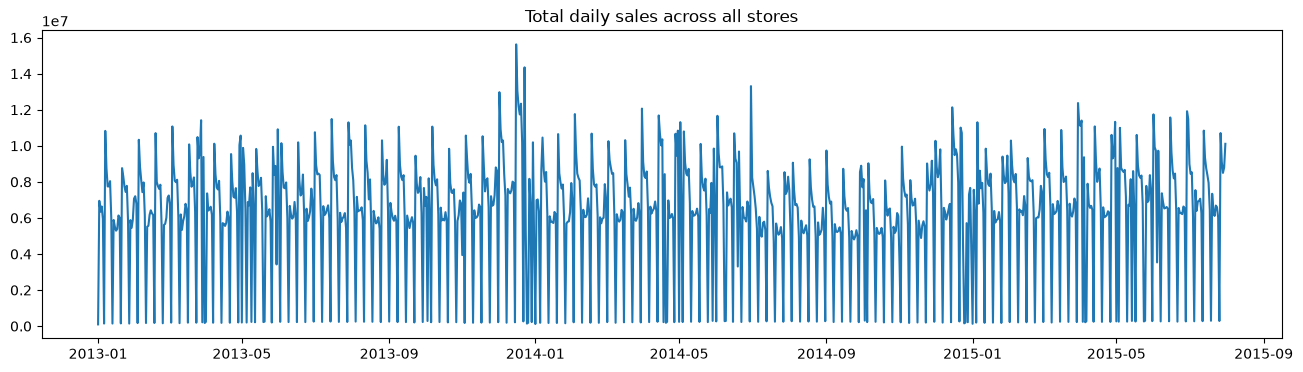

In [16]:
daily_total = open_df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(16, 4))
plt.plot(daily_total.index, daily_total.values)
plt.title('Total daily sales across all stores')
plt.show()

### Individual Store Series

Sampling stores: [2, 85, 1, 13]


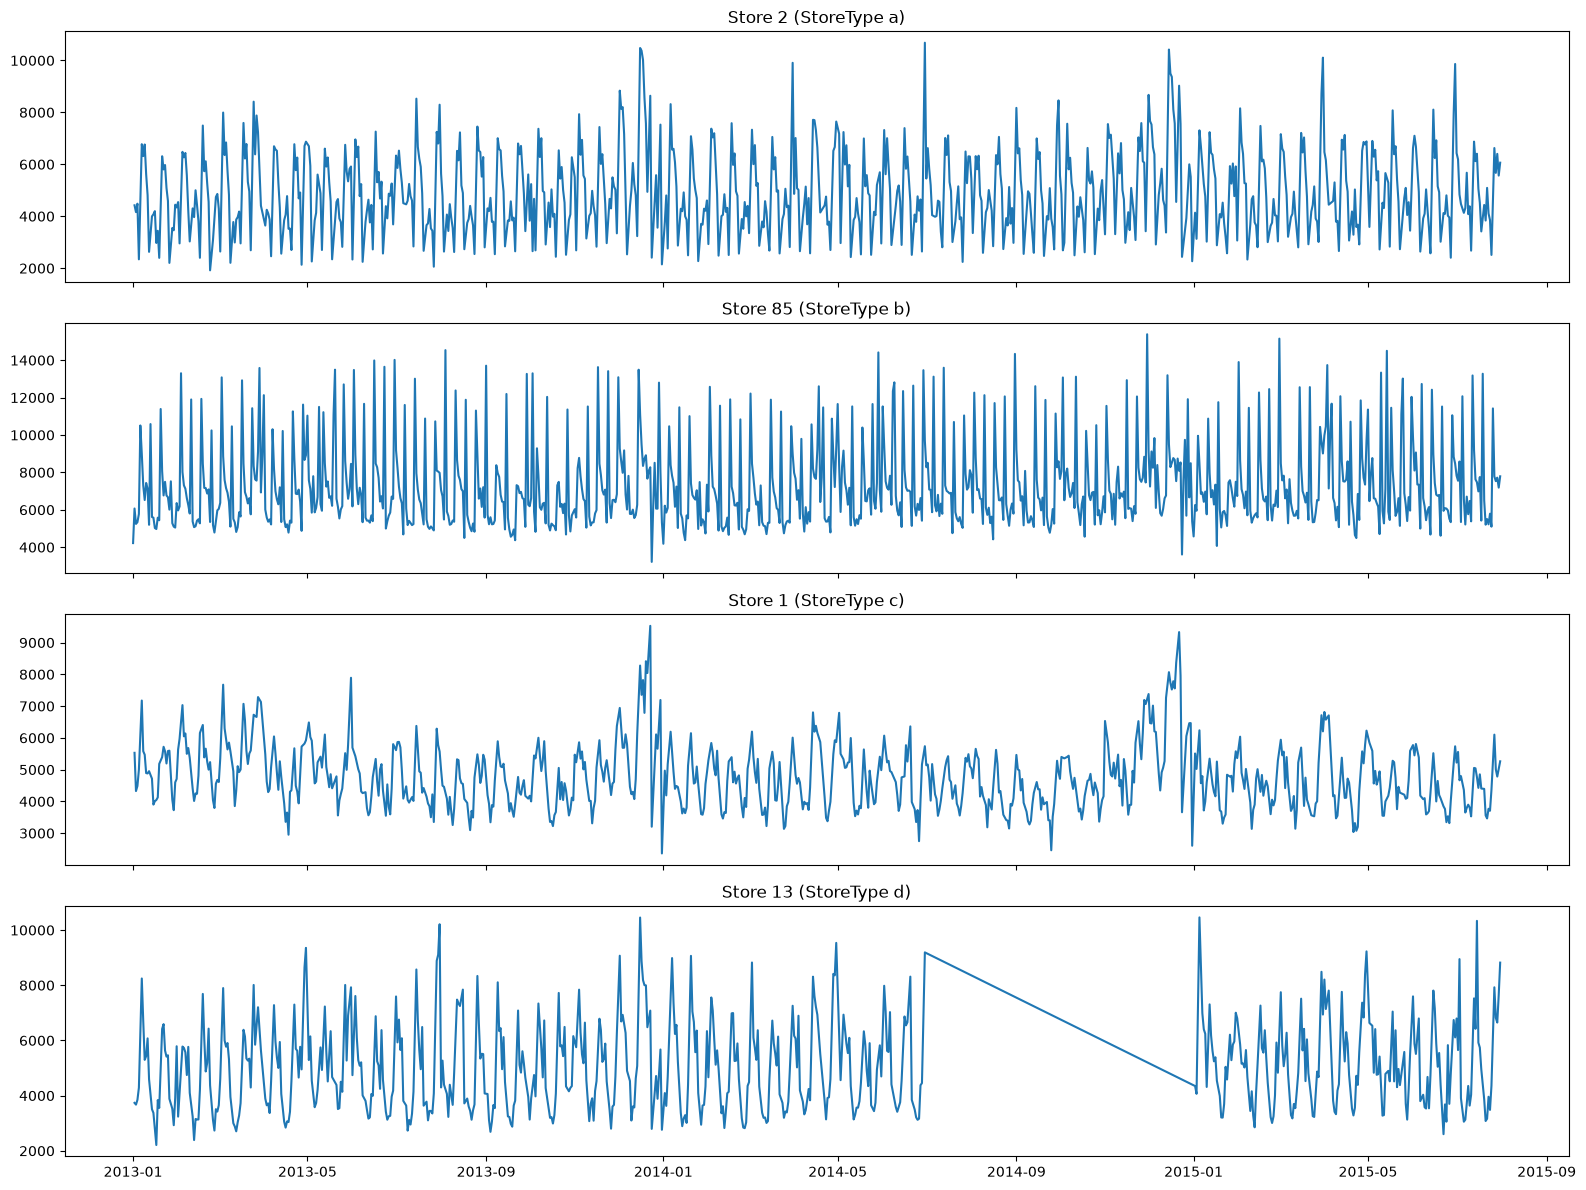

In [17]:
sample_stores = df.groupby('StoreType')['Store'].first().tolist()  # one store per StoreType
print("Sampling stores:", sample_stores)

fig, axes = plt.subplots(len(sample_stores), 1, figsize=(16, 3*len(sample_stores)), sharex=True)
for ax, s in zip(axes, sample_stores):
    store_series = df[(df['Store'] == s) & (df['Open'] == 1)].sort_values('Date')
    ax.plot(store_series['Date'], store_series['Sales'])
    st = df[df['Store'] == s]['StoreType'].iloc[0]
    ax.set_title(f'Store {s} (StoreType {st})')
plt.tight_layout()
plt.show()

### Sales by Day of the Week

<Figure size 800x400 with 0 Axes>

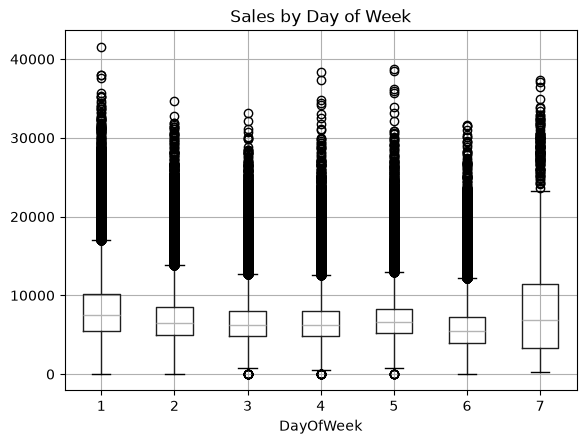

                  mean  median   count
DayOfWeek                             
1          8216.073074  7539.0  137560
2          7088.113656  6502.0  143961
3          6728.122978  6210.0  141936
4          6767.310159  6246.0  134644
5          7072.677012  6580.0  138640
6          5874.840238  5425.0  144058
7          8224.723908  6876.0    3593


In [18]:
plt.figure(figsize=(8, 4))
open_df.boxplot(column='Sales', by='DayOfWeek')
plt.title('Sales by Day of Week')
plt.suptitle('')
plt.show()

print(open_df.groupby('DayOfWeek')['Sales'].agg(['mean', 'median', 'count']))

### Sales by Month

<Figure size 1000x400 with 0 Axes>

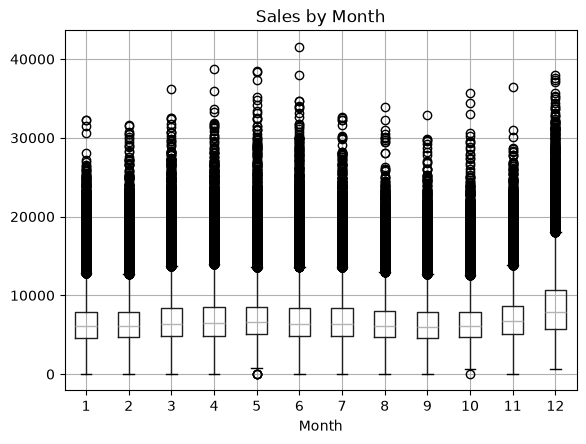

              mean  median  count
Month                            
1      6563.690444  6062.0  86343
2      6589.165535  6078.0  80243
3      6976.412026  6385.0  85980
4      7046.228420  6431.0  81731
5      7106.453154  6592.0  80103
6      7000.978190  6365.0  82576
7      6952.682125  6407.0  85587
8      6648.984654  6124.0  54413
9      6546.343035  5999.0  52330
10     6602.843354  6105.0  53292
11     7188.554250  6691.0  51401
12     8608.956661  7858.0  50393


In [19]:
open_df = open_df.copy()
open_df['Month'] = open_df['Date'].dt.month

plt.figure(figsize=(10, 4))
open_df.boxplot(column='Sales', by='Month')
plt.title('Sales by Month')
plt.suptitle('')
plt.show()

print(open_df.groupby('Month')['Sales'].agg(['mean', 'median', 'count']))

### State Holiday and School holiday effect

In [20]:
print("=== StateHoliday value counts ===")
print(df['StateHoliday'].value_counts())
print()
print("=== Sales by StateHoliday (open days only) ===")
print(open_df.groupby('StateHoliday')['Sales'].agg(['mean', 'median', 'count']))
print()
print("=== Sales by SchoolHoliday ===")
print(open_df.groupby('SchoolHoliday')['Sales'].agg(['mean', 'median', 'count']))

=== StateHoliday value counts ===
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

=== Sales by StateHoliday (open days only) ===
                     mean  median   count
StateHoliday                             
0             6701.492117  6163.0  112140
0             6992.158856  6400.0  731342
a             8487.471182  7556.0     694
b             9887.889655  8423.0     145
c             9743.746479  8397.0      71

=== Sales by SchoolHoliday ===
                      mean  median   count
SchoolHoliday                             
0              6896.782411  6326.0  680935
1              7200.181650  6562.0  163457


### Fix holiday type

In [21]:
print("Unique raw values and types:")
for v in df['StateHoliday'].unique():
    print(repr(v), type(v))

# Fix: cast everything to string
df['StateHoliday'] = df['StateHoliday'].astype(str)
open_df['StateHoliday'] = open_df['StateHoliday'].astype(str)

print()
print("After fix:")
print(df['StateHoliday'].value_counts())

Unique raw values and types:
'0' <class 'str'>
'a' <class 'str'>
'b' <class 'str'>
'c' <class 'str'>
0 <class 'int'>

After fix:
StateHoliday
0    986159
a     20260
b      6690
c      4100
Name: count, dtype: int64


### Promo Effects

=== Sales by Promo ===
              mean  median   count
Promo                             
0      5929.407603  5459.0  467496
1      8228.281239  7649.0  376896



<Figure size 600x400 with 0 Axes>

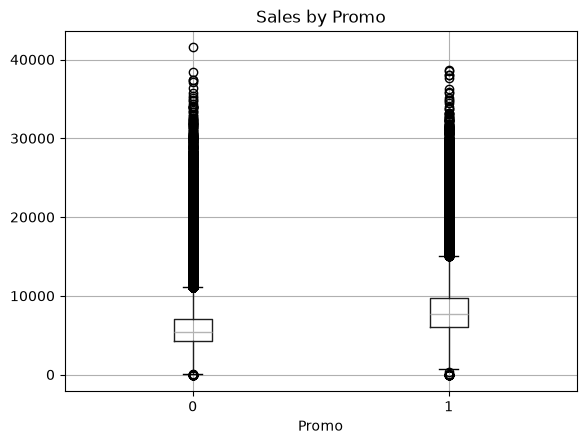

In [22]:
print("=== Sales by Promo ===")
print(open_df.groupby('Promo')['Sales'].agg(['mean', 'median', 'count']))
print()

plt.figure(figsize=(6, 4))
open_df.boxplot(column='Sales', by='Promo')
plt.title('Sales by Promo')
plt.suptitle('')
plt.show()

### Does Promo Effect Vary by Store type

In [23]:
promo_by_type = open_df.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack()
promo_by_type['lift_pct'] = (promo_by_type[1] - promo_by_type[0]) / promo_by_type[0] * 100
print(promo_by_type)

Promo                0             1   lift_pct
StoreType                                      
a          5808.500091   8304.102317  42.964658
b          9566.861686  11307.994108  18.199619
c          6028.063255   8041.995526  33.409276
d          5855.268289   8017.828656  36.933583


### Promo2 (Secondary Promo)

In [24]:
print("=== Promo2 value counts (store-level, not row-level) ===")
print(store['Promo2'].value_counts())
print()

# Promo2 is store-level (always on/off for a store), but PromoInterval tells us WHICH months it's active
# Need to check: for stores with Promo2==1, is the current month in their PromoInterval?
print("=== PromoInterval unique values ===")
print(store['PromoInterval'].value_counts())

=== Promo2 value counts (store-level, not row-level) ===
Promo2
1    571
0    544
Name: count, dtype: int64

=== PromoInterval unique values ===
PromoInterval
Jan,Apr,Jul,Oct     335
Feb,May,Aug,Nov     130
Mar,Jun,Sept,Dec    106
Name: count, dtype: int64


In [25]:
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

df_promo2 = df.copy()
df_promo2['MonthStr'] = df_promo2['Date'].dt.month.map(month_map)
df_promo2['Promo2Active'] = df_promo2.apply(
    lambda r: 1 if (r['Promo2'] == 1 and isinstance(r['PromoInterval'], str) and r['MonthStr'] in r['PromoInterval']) else 0,
    axis=1
)

open_promo2 = df_promo2[df_promo2['Open'] == 1]
print(open_promo2.groupby('Promo2Active')['Sales'].agg(['mean', 'median', 'count']))

                     mean  median   count
Promo2Active                             
0             7051.816202  6440.0  699164
1             6491.892748  6044.0  145228


### Sales by Store Type and Assortment

In [26]:
print("=== Sales by StoreType ===")
print(open_df.groupby('StoreType')['Sales'].agg(['mean', 'median', 'std', 'count']))
print()
print("=== Sales by Assortment ===")
print(open_df.groupby('Assortment')['Sales'].agg(['mean', 'median', 'std', 'count']))
print()
print("=== StoreType x Assortment combos (counts) ===")
print(store.groupby(['StoreType', 'Assortment']).size().unstack(fill_value=0))

=== Sales by StoreType ===
                   mean  median          std   count
StoreType                                           
a           6925.167661  6285.0  3277.786381  457077
b          10231.407505  9130.0  5157.190155   15563
c           6932.512755  6407.0  2897.564578  112978
d           6822.141881  6395.0  2556.582881  258774

=== Sales by Assortment ===
                   mean  median          std   count
Assortment                                          
a           6621.017039  6082.0  2972.500222  444909
b           8639.346322  8081.0  3806.006716    8212
c           7300.526339  6675.0  3184.144215  391271

=== StoreType x Assortment combos (counts) ===
Assortment    a  b    c
StoreType              
a           381  0  221
b             7  9    1
c            77  0   71
d           128  0  220


### CompetitionDistance Relationship with Sales

Correlation (CompetitionDistance vs avg store sales): -0.04243057582013184

Nulls in CompetitionDistance: 3


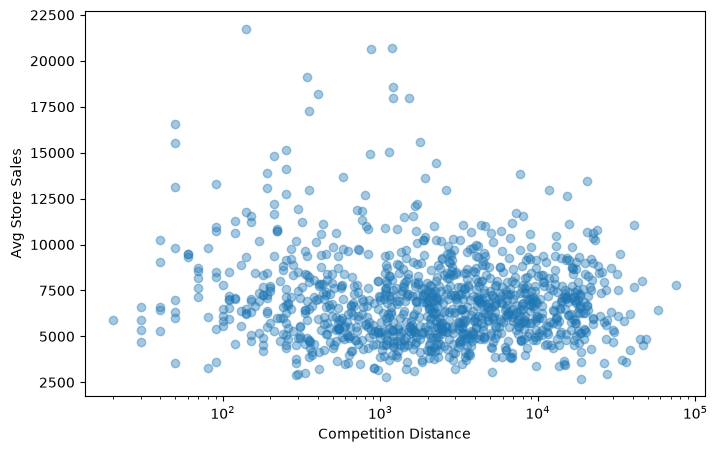

In [27]:
store_avg_sales = open_df.groupby('Store')['Sales'].mean().reset_index()
store_avg_sales = store_avg_sales.merge(store[['Store', 'CompetitionDistance']], on='Store')

print("Correlation (CompetitionDistance vs avg store sales):", 
      store_avg_sales['CompetitionDistance'].corr(store_avg_sales['Sales']))
print()
print("Nulls in CompetitionDistance:", store_avg_sales['CompetitionDistance'].isnull().sum())

plt.figure(figsize=(8,5))
plt.scatter(store_avg_sales['CompetitionDistance'], store_avg_sales['Sales'], alpha=0.4)
plt.xlabel('Competition Distance')
plt.ylabel('Avg Store Sales')
plt.xscale('log')
plt.show()

### Autocorrelation

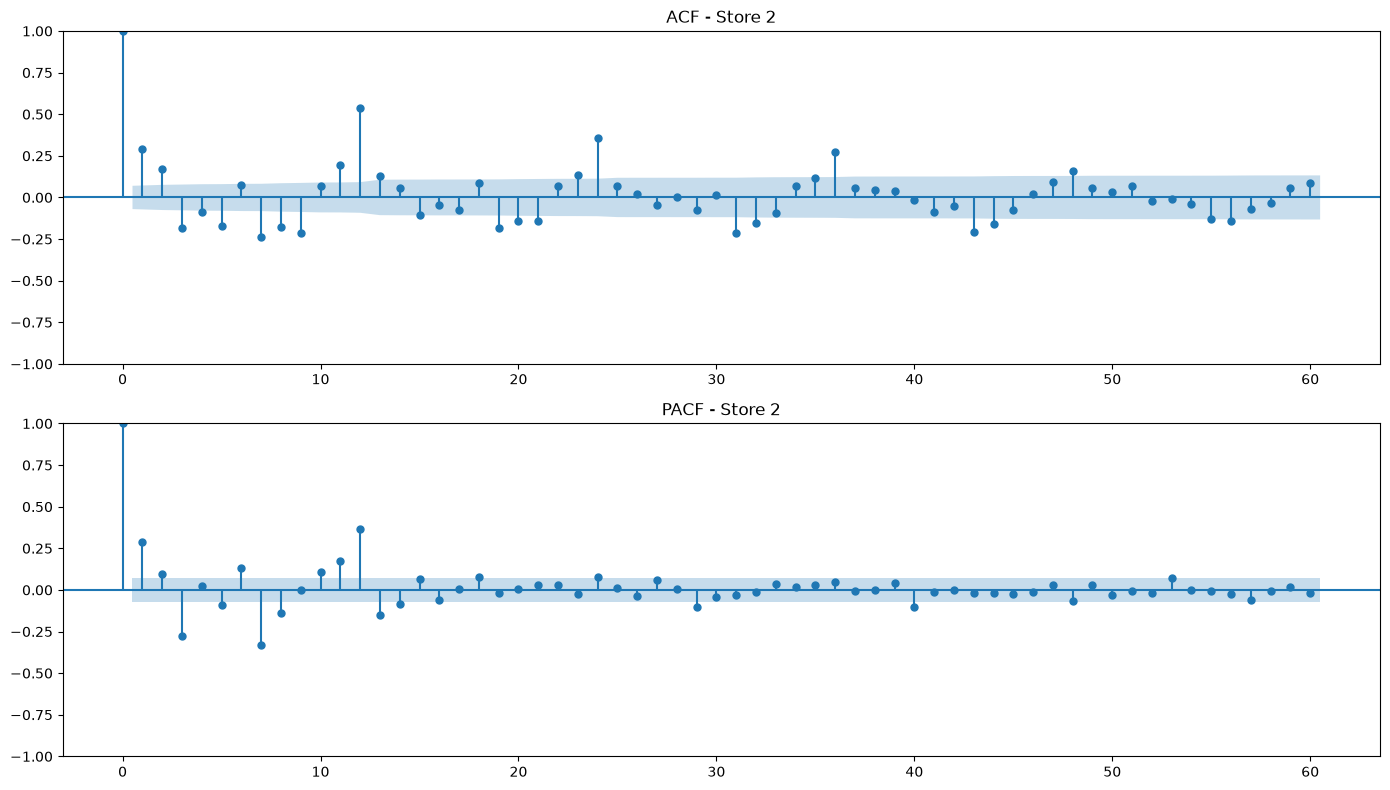

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# pick a store with full history, no big gaps, consistently open
sample_store_id = 2  # StoreType a, seen earlier
s = df[(df['Store'] == sample_store_id) & (df['Open'] == 1)].sort_values('Date')
sales_series = s.set_index('Date')['Sales']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(sales_series, lags=60, ax=axes[0])
axes[0].set_title(f'ACF - Store {sample_store_id}')
plot_pacf(sales_series, lags=60, ax=axes[1])
axes[1].set_title(f'PACF - Store {sample_store_id}')
plt.tight_layout()
plt.show()

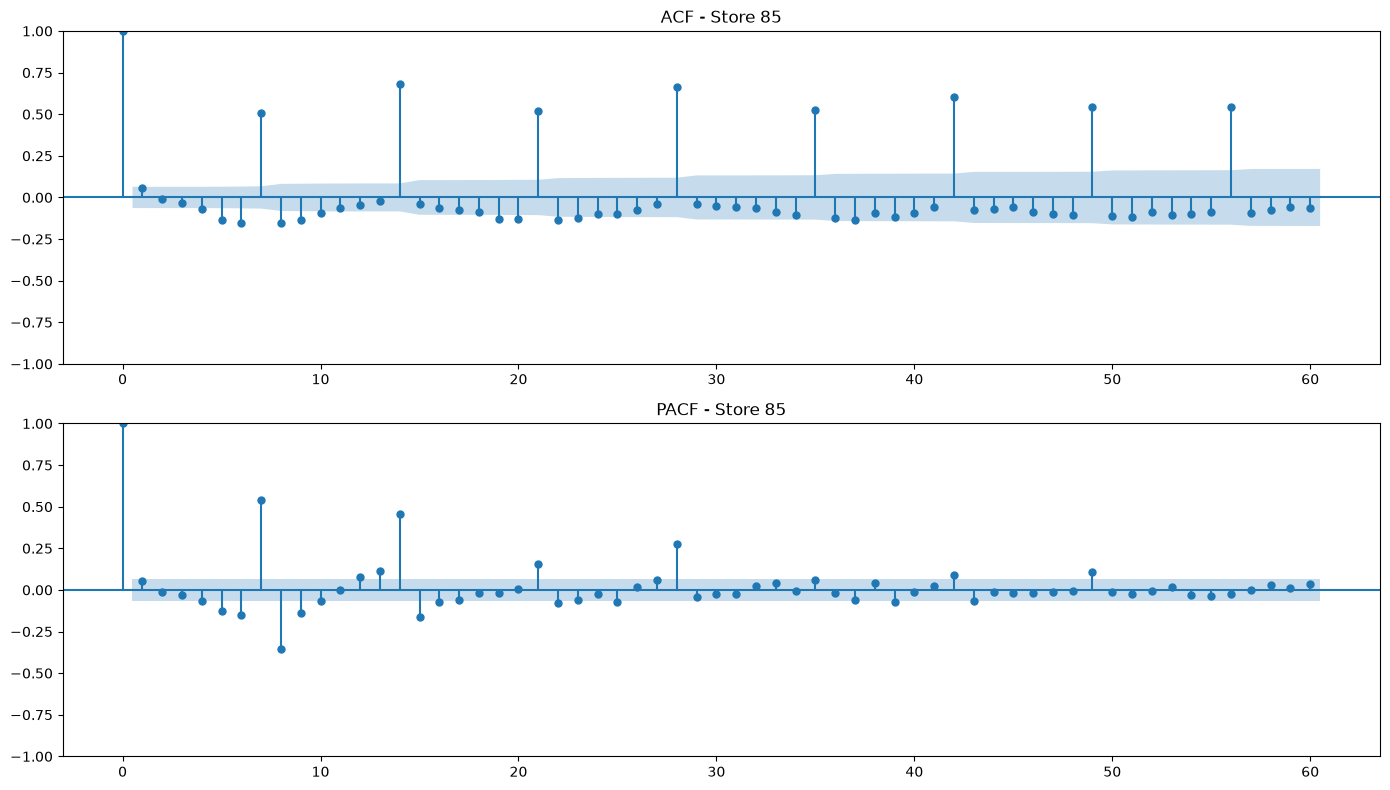

In [29]:
sample_store_id_2 = 85  # StoreType b, higher volume/volatility
s2 = df[(df['Store'] == sample_store_id_2) & (df['Open'] == 1)].sort_values('Date')
sales_series_2 = s2.set_index('Date')['Sales']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(sales_series_2, lags=60, ax=axes[0])
axes[0].set_title(f'ACF - Store {sample_store_id_2}')
plot_pacf(sales_series_2, lags=60, ax=axes[1])
axes[1].set_title(f'PACF - Store {sample_store_id_2}')
plt.tight_layout()
plt.show()

In [30]:
print("Stores with CompetitionDistance present but CompetitionOpenSinceYear null:")
mask = store['CompetitionDistance'].notnull() & store['CompetitionOpenSinceYear'].isnull()
print(mask.sum(), "out of", store['CompetitionDistance'].notnull().sum())

print()
print("Stores with Promo2==0 but Promo2SinceWeek not null (should be 0):")
print(((store['Promo2'] == 0) & (store['Promo2SinceWeek'].notnull())).sum())

print()
print("Stores with Promo2==1 but Promo2SinceWeek null (should be 0):")
print(((store['Promo2'] == 1) & (store['Promo2SinceWeek'].isnull())).sum())

Stores with CompetitionDistance present but CompetitionOpenSinceYear null:
351 out of 1112

Stores with Promo2==0 but Promo2SinceWeek not null (should be 0):
0

Stores with Promo2==1 but Promo2SinceWeek null (should be 0):
0


## Modeling Plan Summary

**Target variable**: `log1p(Sales)`, predictions inverted via `expm1` at inference time.
Raw sales skew = 1.59; log1p reduces this to -0.64. Log transform also naturally
prevents negative predictions and treats proportional swings consistently across
low- and high-volume stores.

**Evaluation metric**: WMAPE (weighted MAPE), not plain MAPE — plain MAPE is
unstable near-zero sales days, which exist in this dataset (54 open days with
Sales==0). WMAPE weights by actual sales volume, which better reflects business
impact and avoids blowing up on edge cases. Report RMSE alongside as a secondary
metric since it penalizes large absolute misses, which matters for inventory
planning use cases.

**Train/val/test split** (time-respecting, no shuffling):
- Train: 2013-01-01 → 2015-04-30
- Validation: 2015-05-01 → 2015-06-15
- Test: 2015-06-16 → 2015-07-31
(The 181-store closure gap in H2 2014 falls entirely within train — does not
affect val/test integrity.)

**Feature set**:
- Calendar: DayOfWeek, Month, IsWeekend, IsDecember, StateHoliday (cleaned dtype),
  SchoolHoliday
- Promo: Promo, Promo2Active (derived from Promo2 + PromoInterval + current month,
  vectorized — not the slow row-wise apply used in EDA)
- Store metadata: StoreType, Assortment, CompetitionDistance (imputed),
  CompetitionOpenSince* (sentinel-imputed)
- Lag features: sales_lag_1, lag_7, lag_14, lag_21, lag_28 — justified by ACF/PACF
  showing clean weekly-harmonic autocorrelation (Store 85) once computed on a
  correctly calendar-reindexed series
- Rolling features: rolling_mean_7, rolling_std_7, rolling_mean_28, rolling_std_28

**Critical implementation requirement**: all lag/rolling features must be computed
on each store's full calendar-date-reindexed series (including closed days) BEFORE
filtering to Open==1 rows for training. Computing on the Open-filtered row sequence
directly was tested and found to distort the weekly cycle for stores that close on
Sundays (confirmed via ACF comparison between Store 2 and Store 85).

**Model ladder**:
1. Seasonal naive (lag_7) — floor baseline
2. SARIMA — classical baseline on a representative subset of stores
3. LightGBM — primary workhorse, global model across all stores with StoreID as
   a categorical feature
4. LightGBM + Optuna-tuned — systematic hyperparameter search
5. N-BEATS or TFT (neuralforecast) — global deep learning comparison

**Known limitations** (documented honestly, not hidden):
- Only 2.5 years of history — yearly seasonality is weakly estimated at best
- CompetitionDistance shows no linear correlation with sales; kept as a feature
  for tree-based models to exploit non-linearly, but not expected to be
  high-importance
- Promo2 shows a counter-intuitive negative raw association with sales, likely
  due to confounding (which stores opt into recurring promos); kept as a feature
  but not interpreted causally